In [38]:
import numpy as np
import pandas as pd
import csv
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 500)
from tqdm.auto import tqdm

import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei']  # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号

In [39]:
weather_data = pd.read_csv("data/A榜-训练集_分布式光伏发电预测_气象变量数据.csv",encoding = 'gbk')
weather_data = weather_data[['光伏用户编号','时间','辐照强度（J/m2）','温度（K）']]

In [40]:
from datetime import datetime, timedelta
power_data = pd.read_csv("data\A榜-训练集_分布式光伏发电预测_实际功率数据.csv",encoding = 'gbk')

df = pd.DataFrame(power_data)

# 创建以15分钟为间隔的数据
new_data = []
start_date = datetime(2022, 1, 3, 0, 0)  # 起始时间为2022-01-03 00:00
for i in range(df.shape[0]):
    row = df.iloc[i]
    for j in range(1, 97):
        time = start_date + timedelta(minutes=15*(j-1))
        new_data.append([row['光伏用户编号'], time])

# Convert '时间' column to datetime64 data type
weather_data['时间'] = pd.to_datetime(weather_data['时间'])
power_data['时间'] = pd.to_datetime(power_data['时间'])

power_data_drop = pd.DataFrame(new_data, columns=['光伏用户编号', '时间'])
train_data = pd.merge(power_data_drop, weather_data, on=['光伏用户编号', '时间'],how='left')
train_data['光伏用户编号'].replace({'f1': '1', 'f2': '2', 'f3': '3', 'f4': '4', 'f5': '5',
                   'f6': '6', 'f7': '7', 'f8': '8', 'f9': '9'}, inplace=True)
train_data

,光伏用户编号,时间,辐照强度（J/m2）,温度（K）
0,1,2022-01-03 00:00:00,0.0,280.6320
1,1,2022-01-03 00:15:00,0.0,280.6308
2,1,2022-01-03 00:30:00,0.0,280.5719
3,1,2022-01-03 00:45:00,0.0,280.4776
4,1,2022-01-03 01:00:00,0.0,280.3705
...,...,...,...,...
416347,9,2022-01-03 22:45:00,0.0,285.0616
416348,9,2022-01-03 23:00:00,0.0,285.0117
416349,9,2022-01-03 23:15:00,0.0,284.9275
416350,9,2022-01-03 23:30:00,0.0,284.8174


In [41]:
from sklearn.preprocessing import MinMaxScaler
n_tasks = 96
# 特征工程
train_data['时间'] = pd.to_datetime(train_data['时间'])
train_data['月份'] = train_data['时间'].dt.month
train_data['日期'] = train_data['时间'].dt.day
train_data['小时'] = train_data['时间'].dt.hour
train_data['分钟'] = train_data['时间'].dt.minute

# 按时间排序数据
X_train = train_data.sort_values(by='时间')

X_train = pd.DataFrame(X_train)

# 选择特征和目标变量
X_train = X_train.drop('时间', axis=1)

# 标准化或归一化特征
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)

n_features = X_train.shape[1]
X_train

array([[0.        , 0.        , 0.16661925, ..., 0.        , 0.        ,
        0.        ],
       [0.125     , 0.        , 0.41880367, ..., 0.        , 0.        ,
        0.        ],
       [0.875     , 0.        , 0.30994583, ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.25      , 0.        , 0.34652787, ..., 0.        , 1.        ,
        1.        ],
       [0.25      , 0.        , 0.34652787, ..., 0.        , 1.        ,
        1.        ],
       [1.        , 0.        , 0.4025824 , ..., 0.        , 1.        ,
        1.        ]])

In [42]:
X_train = np.ravel(X_train)
len(X_train)
# X_train 转换为(n_samples, n_tasks, n_features)
n_tasks = 96  # 假设有2个任务
n_features = 7

# 将 X_train 重塑为 (n_samples, n_tasks, n_features) 的形状
X_train = X_train.reshape(-1, n_tasks, n_features)
print(X_train.shape)

(4337, 96, 7)


In [43]:
y_train = power_data[['p1', 'p2', 'p3', 'p4', 'p5', 'p6', 'p7', 'p8', 'p9', 'p10', 'p11', 'p12', 'p13', 'p14', 'p15', 'p16', 'p17', 'p18', 'p19', 'p20', 'p21', 'p22', 'p23', 'p24', 'p25', 'p26', 'p27', 'p28', 'p29', 'p30', 'p31', 'p32', 'p33', 'p34', 'p35', 'p36', 'p37', 'p38', 'p39', 'p40', 'p41', 'p42', 'p43', 'p44', 'p45', 'p46', 'p47', 'p48', 'p49', 'p50', 'p51', 'p52', 'p53', 'p54', 'p55', 'p56', 'p57', 'p58', 'p59', 'p60', 'p61', 'p62', 'p63', 'p64', 'p65', 'p66', 'p67', 'p68', 'p69', 'p70', 'p71', 'p72', 'p73', 'p74', 'p75', 'p76', 'p77', 'p78', 'p79', 'p80', 'p81', 'p82', 'p83', 'p84', 'p85', 'p86', 'p87', 'p88', 'p89', 'p90', 'p91', 'p92', 'p93', 'p94', 'p95', 'p96']]
n_tasks = 96
y_train = np.ravel(y_train)
# 调整y_train的形状为(n_samples, n_tasks)
y_train = y_train.reshape(-1, n_tasks)

y_train.shape

(4337, 96)

In [44]:
weather_test = pd.read_csv("data/A榜-测试集_分布式光伏发电预测_气象变量数据.csv",encoding = 'gbk')
weather_test = weather_test[['光伏用户编号','时间','辐照强度（J/m2）','温度（K）']]
power_test = pd.read_csv("data\A榜-测试集_分布式光伏发电预测_实际功率数据.csv",encoding = 'gbk')

In [45]:
df = pd.DataFrame(power_test)

# 创建新的DataFrame,将p1到p96作为行索引
new_data = []
start_date = datetime(2023, 5, 1, 0, 0)
for i in range(df.shape[0]):
    row = df.iloc[i]
    for j in range(1, 97):
        time = start_date + timedelta(minutes=15*(j-1))
        new_data.append([row['光伏用户编号'], time])

power_test = pd.DataFrame(new_data, columns=['光伏用户编号', '时间'])
power_test['光伏用户编号'].replace({'f1': '1', 'f2': '2', 'f3': '3', 'f4': '4', 'f5': '5',
                   'f6': '6', 'f7': '7', 'f8': '8', 'f9': '9'}, inplace=True)
power_test

,光伏用户编号,时间
0,1,2023-05-01 00:00:00
1,1,2023-05-01 00:15:00
2,1,2023-05-01 00:30:00
3,1,2023-05-01 00:45:00
4,1,2023-05-01 01:00:00
...,...,...
79195,9,2023-05-01 22:45:00
79196,9,2023-05-01 23:00:00
79197,9,2023-05-01 23:15:00
79198,9,2023-05-01 23:30:00


In [46]:
# Convert '时间' column to datetime64 data type
weather_test['时间'] = pd.to_datetime(weather_test['时间'])
power_test['时间'] = pd.to_datetime(power_test['时间'])
# Now merge the DataFrames
test_data = pd.merge(power_test,weather_test, on=['光伏用户编号','时间'],how='left')
# 特征工程
test_data['时间'] = pd.to_datetime(test_data['时间'])
test_data['月份'] = test_data['时间'].dt.month
test_data['日期'] = test_data['时间'].dt.day
test_data['小时'] = test_data['时间'].dt.hour
test_data['分钟'] = test_data['时间'].dt.minute
test_data = test_data.drop('时间', axis=1)
test_data['辐照强度（J/m2）'] = weather_test['辐照强度（J/m2）']
test_data['温度（K）'] = weather_test['温度（K）']
test_data

,光伏用户编号,辐照强度（J/m2）,温度（K）,月份,日期,小时,分钟
0,1,0.0,287.6853,5,1,0,0
1,1,0.0,287.7061,5,1,0,15
2,1,0.0,287.6017,5,1,0,30
3,1,0.0,287.4312,5,1,0,45
4,1,0.0,287.2534,5,1,1,0
...,...,...,...,...,...,...,...
79195,9,0.0,298.5737,5,1,22,45
79196,9,0.0,298.5271,5,1,23,0
79197,9,0.0,298.6875,5,1,23,15
79198,9,0.0,298.9674,5,1,23,30


In [47]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import OneHotEncoder

X_test = pd.DataFrame(test_data)

# 标准化或归一化特征
scaler = MinMaxScaler()
X_test = scaler.fit_transform(X_test)
X_test = np.ravel(X_test)
X_test = X_test.reshape(-1, n_tasks, n_features)

X_test.shape

(825, 96, 7)

D:\anaconda1\envs\pm3env\lib\site-packages\pymc3\model.py:1755: ImputationWarning: Data in Y_obs contains missing values and will be automatically imputed from the sampling distribution.
  warnings.warn(impute_message, ImputationWarning)
D:\anaconda1\envs\pm3env\lib\site-packages\deprecat\classic.py:215: FutureWarning: In v4.0, pm.sample will return an `arviz.InferenceData` object instead of a `MultiTrace` by default. You can pass return_inferencedata=True or return_inferencedata=False to be safe and silence this warning.
  return wrapped_(*args_, **kwargs_)
Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [Y_obs_missing, sigma, beta, alpha]


Sampling 2 chains for 1_000 tune and 500 draw iterations (2_000 + 1_000 draws total) took 1436 seconds.
Got error No model on context stack. trying to find log_likelihood in translation.
D:\anaconda1\envs\pm3env\lib\site-packages\arviz\data\io_pymc3_3x.py:98: FutureWarning: Using `from_pymc3` without the model will be deprecated in a future release. Not using the model will return less accurate and less useful results. Make sure you use the model argument or call from_pymc3 within a model context.
  warnings.warn(
Got error No model on context stack. trying to find log_likelihood in translation.


                      mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  \
alpha                0.433  0.002   0.428    0.438      0.000    0.000   
beta[0]              0.018  0.002   0.014    0.022      0.000    0.000   
beta[1]              0.090  0.004   0.083    0.097      0.000    0.000   
beta[2]             -0.242  0.006  -0.253   -0.231      0.000    0.000   
beta[3]             -0.043  1.002  -1.826    1.894      0.031    0.038   
...                    ...    ...     ...      ...        ...      ...   
Y_obs_missing[6520]  0.209  0.462  -0.668    1.026      0.014    0.015   
Y_obs_missing[6521]  0.139  0.482  -0.784    0.982      0.013    0.020   
Y_obs_missing[6522]  0.136  0.470  -0.773    0.950      0.014    0.016   
Y_obs_missing[6523]  0.155  0.464  -0.617    1.036      0.012    0.015   
sigma                0.475  0.000   0.474    0.476      0.000    0.000   

                     ess_bulk  ess_tail  r_hat  
alpha                   746.0     685.0   1.00  
beta[0]      

D:\anaconda1\envs\pm3env\lib\site-packages\arviz\data\io_pymc3_3x.py:98: FutureWarning: Using `from_pymc3` without the model will be deprecated in a future release. Not using the model will return less accurate and less useful results. Make sure you use the model argument or call from_pymc3 within a model context.
  warnings.warn(
Got error No model on context stack. trying to find log_likelihood in translation.


array([[<Axes: title={'center': 'alpha'}>,
        <Axes: title={'center': 'alpha'}>],
       [<Axes: title={'center': 'beta'}>,
        <Axes: title={'center': 'beta'}>],
       [<Axes: title={'center': 'Y_obs_missing'}>,
        <Axes: title={'center': 'Y_obs_missing'}>],
       [<Axes: title={'center': 'sigma'}>,
        <Axes: title={'center': 'sigma'}>]], dtype=object)

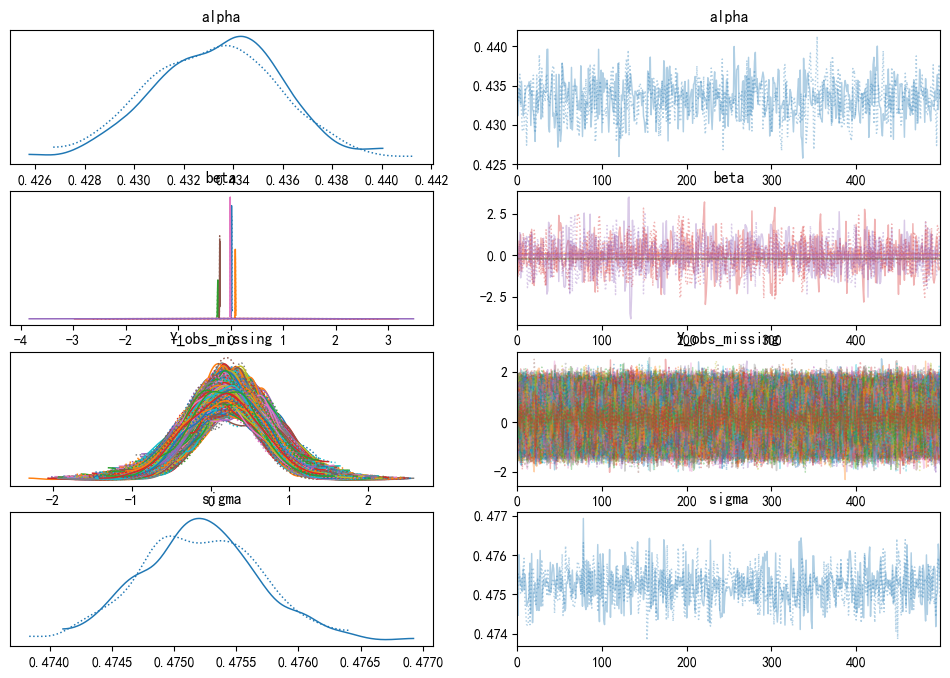

In [48]:
import pymc3 as pm
import numpy as np
import theano.tensor as tt

N, N_tasks, N_features = X_train.shape
N_test, N_tasks, N_features = X_test.shape

# 处理数据中的零值，将零值替换为非零小值
X_train_clean = np.where(X_train == 0, 1e-6, X_train)
y_train_clean = np.where(y_train == 0, 1e-6, y_train)

with pm.Model() as multi_task_model:
    # Define priors
    alpha = pm.Normal('alpha', mu=0, sigma=1)
    beta = pm.Normal('beta', mu=0, sigma=1, shape=N_features)
    sigma = pm.HalfNormal('sigma', sigma=1)

    # Define multi-task regression model with cleaned data
    mu = alpha + tt.dot(X_train_clean, beta)
    mu = mu.reshape(y_train_clean.shape)  # Reshape mu to match y_train_clean
    Y_obs = pm.Normal('Y_obs', mu=mu, sigma=sigma, observed=y_train_clean)

    # Sampling
    trace = pm.sample(500, chains=2, cores=2)  # 增加迭代次数以更好地诊断收敛情况

# 查看参数统计汇总
print(pm.summary(trace))

# 绘制迭代轨迹图
pm.plot_trace(trace)

In [49]:
import pymc3 as pm
import numpy as np
import theano
import theano.tensor as tt

# 其他代码保持不变
...

# 从后验分布中抽取参数
alpha_samples = trace['alpha']
beta_samples = trace['beta']

# 编译一个函数来计算预测均值
mu_test_func = theano.function([alpha, beta], alpha + tt.dot(X_test, beta))

# 预测
preds = []
for i in range(len(alpha_samples)):
    alpha_sample = alpha_samples[i]
    beta_sample = beta_samples[i]
    
    # 计算测试集的预测均值
    mu_test = mu_test_func(alpha_sample, beta_sample)
    preds.append(mu_test)

# 将预测结果转换为NumPy数组
preds = np.array(preds)

# 计算预测均值
mean_preds = np.mean(preds, axis=0)

# 打印预测结果
print("预测结果形状：", mean_preds.shape)
print("预测结果：\n", mean_preds)

预测结果形状： (825, 96)
预测结果：
 [[0.39308632 0.39100096 0.38990743 ... 0.17689309 0.17928201 0.18183016]
 [0.39867994 0.400527   0.40161832 ... 0.14839816 0.14896347 0.14955412]
 [0.36402972 0.36295362 0.36104176 ... 0.13058982 0.12944717 0.1286008 ]
 ...
 [0.29761909 0.29636712 0.29520229 ... 0.08317105 0.08175748 0.08035974]
 [0.2934102  0.2918873  0.29027727 ... 0.11312281 0.10866803 0.1039249 ]
 [0.31444908 0.31206428 0.31100164 ... 0.11501535 0.11087744 0.10677122]]


In [50]:
power_test = pd.read_csv("data\A榜-测试集_分布式光伏发电预测_实际功率数据.csv",encoding = 'gbk')
power_test

,光伏用户编号,综合倍率,时间
0,f1,80,2023-5-1 0:00
1,f1,80,2023-5-2 0:00
2,f1,80,2023-5-3 0:00
3,f1,80,2023-5-4 0:00
4,f1,80,2023-5-5 0:00
...,...,...,...
820,f9,8000,2023-7-27 0:00
821,f9,8000,2023-7-30 0:00
822,f9,8000,2023-7-31 0:00
823,f9,8000,2023-5-15 0:00


In [51]:
# 重构预测结果
y_pred = mean_preds.reshape(N_test, N_tasks)
print(len(y_pred))
y_pred_df = pd.DataFrame(y_pred, columns=['p'+str(i) for i in range(1,97)])

# 在 power_test 中创建 p1 到 p96 列
for i in range(1, 97):
    power_test[f'p{i}'] = 0

# 将 y_pred_df 中的值拼接到 power_test 中对应的列
for col in y_pred_df.columns:
    power_test[col] = y_pred_df[col].values
power_test

825


,光伏用户编号,综合倍率,时间,p1,p2,p3,p4,p5,p6,p7,p8,p9,p10,p11,p12,p13,p14,p15,p16,p17,p18,p19,p20,p21,p22,p23,p24,p25,p26,p27,p28,p29,p30,p31,p32,p33,p34,p35,p36,p37,p38,p39,p40,p41,p42,p43,p44,p45,p46,p47,p48,p49,p50,p51,p52,p53,p54,p55,p56,p57,p58,p59,p60,p61,p62,p63,p64,p65,p66,p67,p68,p69,p70,p71,p72,p73,p74,p75,p76,p77,p78,p79,p80,p81,p82,p83,p84,p85,p86,p87,p88,p89,p90,p91,p92,p93,p94,p95,p96
0,f1,80,2023-5-1 0:00,0.393086,0.391001,0.389907,0.389338,0.387516,0.386698,0.385624,0.384447,0.382013,0.381049,0.380182,0.379302,0.376994,0.375784,0.374343,0.372671,0.369456,0.367352,0.365238,0.363337,0.360563,0.359592,0.358493,0.356478,0.351451,0.345539,0.338132,0.330226,0.333711,0.331786,0.331267,0.331588,0.330877,0.331290,0.331468,0.331462,0.330018,0.329782,0.329382,0.328733,0.326439,0.325065,0.323378,0.321489,0.318196,0.316208,0.314217,0.312208,0.308853,0.306752,0.304568,0.302274,0.298530,0.295938,0.293221,0.290418,0.286264,0.283399,0.280463,0.277386,0.272790,0.269229,0.265352,0.261122,0.255193,0.250226,0.245266,0.240749,0.235797,0.233260,0.231240,0.228943,0.224269,0.219307,0.213280,0.206981,0.198737,0.195187,0.192033,0.189355,0.185924,0.184394,0.183302,0.182454,0.180338,0.179425,0.178457,0.177534,0.175445,0.174918,0.174786,0.175202,0.175009,0.176893,0.179282,0.181830
1,f1,80,2023-5-2 0:00,0.398680,0.400527,0.401618,0.401730,0.399328,0.396946,0.393722,0.390240,0.385776,0.383381,0.381569,0.380015,0.377081,0.375132,0.372895,0.370478,0.366680,0.364211,0.361785,0.359406,0.355771,0.353428,0.350701,0.347148,0.341020,0.334697,0.327459,0.320102,0.322791,0.319517,0.316873,0.314542,0.310899,0.308321,0.305569,0.302788,0.298815,0.296364,0.294033,0.291679,0.287849,0.285074,0.282173,0.279329,0.275414,0.273154,0.271048,0.268826,0.264911,0.261753,0.258278,0.254821,0.250409,0.247872,0.245618,0.243240,0.239023,0.235322,0.231126,0.226881,0.221720,0.218585,0.216014,0.213737,0.210171,0.207722,0.205096,0.202365,0.198292,0.195569,0.192952,0.190509,0.186995,0.185077,0.183426,0.182004,0.179105,0.178363,0.177412,0.176216,0.173429,0.171667,0.169754,0.167860,0.164842,0.163419,0.162114,0.160693,0.157609,0.155366,0.153005,0.150992,0.148489,0.148398,0.148963,0.149554
2,f1,80,2023-5-3 0:00,0.364030,0.362954,0.361042,0.358694,0.355001,0.352902,0.351095,0.349511,0.346769,0.345423,0.344113,0.342793,0.340108,0.338637,0.337048,0.335325,0.332144,0.330129,0.328076,0.326112,0.323055,0.321564,0.320019,0.318024,0.313872,0.309900,0.304973,0.299382,0.301577,0.298900,0.296625,0.294809,0.292200,0.291384,0.290669,0.289583,0.286348,0.283335,0.279889,0.276887,0.273899,0.273958,0.274332,0.273133,0.267164,0.257947,0.246220,0.234820,0.225275,0.222183,0.222786,0.224783,0.224560,0.222993,0.219283,0.214499,0.208401,0.204418,0.200989,0.197605,0.192447,0.187785,0.182621,0.177426,0.171366,0.167424,0.164229,0.161604,0.158070,0.156110,0.154433,0.153099,0.150853,0.150338,0.150132,0.150088,0.147685,0.148510,0.148746,0.148782,0.147698,0.148370,0.149210,0.149806,0.148437,0.147435,0.145699,0.143563,0.140051,0.138055,0.136282,0.134691,0.131927,0.130590,0.129447,0.128601
3,f1,80,2023-5-4 0:00,0.342639,0.342622,0.342817,0.342934,0.341380,0.340568,0.339311,0.337817,0.334982,0.333598,0.332397,0.331389,0.329275,0.328658,0.328121,0.327534,0.325459,0.324414,0.323132,0.321685,0.318837,0.317186,0.315036,0.311903,0.305998,0.299652,0.292048,0.283873,0.286957,0.283126,0.279869,0.276896,0.272611,0.269446,0.266319,0.263559,0.260183,0.258956,0.257976,0.256470,0.252352,0.247796,0.242371,0.237281,0.232423,0.231164,0.231104,0.230694,0.227078,0.221866,0.214915,0.207929,0.201308,0.198890,0.198652,0.199395,0.198610,0.197985,0.196367,0.194175,0.190527,0.188350,0.186196,0.183812,0.179638,0.176138,0.172250,0.168319,0.163380,0.160313,0.157733,0.155475,0.152070,0.150020,0.148100,0.146436,0.142759,0.142971,0.142846,0.142487,0.140690,0.140144,0.139492,0.138651,0.136230,0.134811,0.133230,0.131673,0.129023,0.128012,0.127149,0.126180,0.123540,0.121652,0.119253,0.116446
4,f1,80,2023-5-5 0:00,0.327828,0.324553,0.321345,0.318467,0.31487

In [52]:

power_test = power_test.round(4)

# 将结果写入CSV文件,编码格式为UTF-8
power_test.to_csv('xxx.csv', encoding='utf-8', index=False)

In [53]:
pd.read_csv("xxx.csv",encoding='utf-8')

,光伏用户编号,综合倍率,时间,p1,p2,p3,p4,p5,p6,p7,p8,p9,p10,p11,p12,p13,p14,p15,p16,p17,p18,p19,p20,p21,p22,p23,p24,p25,p26,p27,p28,p29,p30,p31,p32,p33,p34,p35,p36,p37,p38,p39,p40,p41,p42,p43,p44,p45,p46,p47,p48,p49,p50,p51,p52,p53,p54,p55,p56,p57,p58,p59,p60,p61,p62,p63,p64,p65,p66,p67,p68,p69,p70,p71,p72,p73,p74,p75,p76,p77,p78,p79,p80,p81,p82,p83,p84,p85,p86,p87,p88,p89,p90,p91,p92,p93,p94,p95,p96
0,f1,80,2023-5-1 0:00,0.3931,0.3910,0.3899,0.3893,0.3875,0.3867,0.3856,0.3844,0.3820,0.3810,0.3802,0.3793,0.3770,0.3758,0.3743,0.3727,0.3695,0.3674,0.3652,0.3633,0.3606,0.3596,0.3585,0.3565,0.3515,0.3455,0.3381,0.3302,0.3337,0.3318,0.3313,0.3316,0.3309,0.3313,0.3315,0.3315,0.3300,0.3298,0.3294,0.3287,0.3264,0.3251,0.3234,0.3215,0.3182,0.3162,0.3142,0.3122,0.3089,0.3068,0.3046,0.3023,0.2985,0.2959,0.2932,0.2904,0.2863,0.2834,0.2805,0.2774,0.2728,0.2692,0.2654,0.2611,0.2552,0.2502,0.2453,0.2407,0.2358,0.2333,0.2312,0.2289,0.2243,0.2193,0.2133,0.2070,0.1987,0.1952,0.1920,0.1894,0.1859,0.1844,0.1833,0.1825,0.1803,0.1794,0.1785,0.1775,0.1754,0.1749,0.1748,0.1752,0.1750,0.1769,0.1793,0.1818
1,f1,80,2023-5-2 0:00,0.3987,0.4005,0.4016,0.4017,0.3993,0.3969,0.3937,0.3902,0.3858,0.3834,0.3816,0.3800,0.3771,0.3751,0.3729,0.3705,0.3667,0.3642,0.3618,0.3594,0.3558,0.3534,0.3507,0.3471,0.3410,0.3347,0.3275,0.3201,0.3228,0.3195,0.3169,0.3145,0.3109,0.3083,0.3056,0.3028,0.2988,0.2964,0.2940,0.2917,0.2878,0.2851,0.2822,0.2793,0.2754,0.2732,0.2710,0.2688,0.2649,0.2618,0.2583,0.2548,0.2504,0.2479,0.2456,0.2432,0.2390,0.2353,0.2311,0.2269,0.2217,0.2186,0.2160,0.2137,0.2102,0.2077,0.2051,0.2024,0.1983,0.1956,0.1930,0.1905,0.1870,0.1851,0.1834,0.1820,0.1791,0.1784,0.1774,0.1762,0.1734,0.1717,0.1698,0.1679,0.1648,0.1634,0.1621,0.1607,0.1576,0.1554,0.1530,0.1510,0.1485,0.1484,0.1490,0.1496
2,f1,80,2023-5-3 0:00,0.3640,0.3630,0.3610,0.3587,0.3550,0.3529,0.3511,0.3495,0.3468,0.3454,0.3441,0.3428,0.3401,0.3386,0.3370,0.3353,0.3321,0.3301,0.3281,0.3261,0.3231,0.3216,0.3200,0.3180,0.3139,0.3099,0.3050,0.2994,0.3016,0.2989,0.2966,0.2948,0.2922,0.2914,0.2907,0.2896,0.2863,0.2833,0.2799,0.2769,0.2739,0.2740,0.2743,0.2731,0.2672,0.2579,0.2462,0.2348,0.2253,0.2222,0.2228,0.2248,0.2246,0.2230,0.2193,0.2145,0.2084,0.2044,0.2010,0.1976,0.1924,0.1878,0.1826,0.1774,0.1714,0.1674,0.1642,0.1616,0.1581,0.1561,0.1544,0.1531,0.1509,0.1503,0.1501,0.1501,0.1477,0.1485,0.1487,0.1488,0.1477,0.1484,0.1492,0.1498,0.1484,0.1474,0.1457,0.1436,0.1401,0.1381,0.1363,0.1347,0.1319,0.1306,0.1294,0.1286
3,f1,80,2023-5-4 0:00,0.3426,0.3426,0.3428,0.3429,0.3414,0.3406,0.3393,0.3378,0.3350,0.3336,0.3324,0.3314,0.3293,0.3287,0.3281,0.3275,0.3255,0.3244,0.3231,0.3217,0.3188,0.3172,0.3150,0.3119,0.3060,0.2997,0.2920,0.2839,0.2870,0.2831,0.2799,0.2769,0.2726,0.2694,0.2663,0.2636,0.2602,0.2590,0.2580,0.2565,0.2524,0.2478,0.2424,0.2373,0.2324,0.2312,0.2311,0.2307,0.2271,0.2219,0.2149,0.2079,0.2013,0.1989,0.1987,0.1994,0.1986,0.1980,0.1964,0.1942,0.1905,0.1884,0.1862,0.1838,0.1796,0.1761,0.1723,0.1683,0.1634,0.1603,0.1577,0.1555,0.1521,0.1500,0.1481,0.1464,0.1428,0.1430,0.1428,0.1425,0.1407,0.1401,0.1395,0.1387,0.1362,0.1348,0.1332,0.1317,0.1290,0.1280,0.1271,0.1262,0.1235,0.1217,0.1193,0.1164
4,f1,80,2023-5-5 0:00,0.3278,0.3246,0.3213,0.3185,0.3149,0.3133,0.3123,0.3116,0.3093,0.3080,0.3063,0.3040,0.2998,0.2965,0.2930,0.2899,0.2862,0.2849,0.2844,0.2839,0.2819,0.2803,0.2779,0.2748,0.2696,0.2652,0.2606,0.2563,0.2586,0.2546,0.2505,0.2474,0.2451,0.2468,0.2502,0.2536,0.2543,0.2538,0.2514,0.2482,0.2440,0.2423,0.2416,0.2412,0.2394,0.2384,0.2369,0.2351,0.2320,0.2303,0.2285,0.2262,0.2220,0.2180,0.2133,0.2079,0.2008,0.1947,0.1887,0.1831,0.1769,0.1730,0.1697,0.1667,0.1622,0.1588,0.1551,0.1517,0.1475,0.1452,0.1436,0.1424,0.1401,0.1391,0.1382,0.1375,0.1346,0.1350,0.1354,0.1357,0.1345,0.1346,0.1344,0.1340,0.1320,0.1311,0.1302,0.1293,0.1274,0.1272,0.1271,0.1269,0.1250,0.1236,0.1218,0.1198
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...